# spy-asian-pricer  —  Demo

Arithmetic-average Asian options on **SPY** under **Dupire local volatility**, calibrated from a JWSVI implied vol surface.

Pipeline: Yahoo Finance chains → SVI → JWSVI surface → Dupire LV → Monte Carlo (antithetic + geometric Asian CV) → Greeks.

Open this notebook in Colab via the badge in the README — the cell below will install everything you need.

In [1]:
!pip install -U "spy-asian-pricer[data,plot]" --quiet


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from spy_asian_pricer import (
    calibrate_svi, JWSVIVolSurface, DupireLocalVol, AsianMCPricer,
    compute_greeks,
    check_butterfly_arbitrage, check_calendar_arbitrage, check_spread_arbitrage,
    filter_butterfly_arbitrage,
    fetch_spot, fetch_dividend_yield, fetch_risk_free_rate, build_vol_grid,
    SSVISurface, calibrate_ssvi,
)

np.random.seed(42)


## 1. Pull market data and calibrate two surfaces (JWSVI + SSVI)


In [15]:
spot = fetch_spot('SPY')
q = fetch_dividend_yield('SPY')              # ~1.3% for SPY (auto-normalized)
# Yahoo ^IRX (13-week T-bill) is the standard short-end proxy.  For longer
# Asian tenors pass tenor_years to interpolate up the Treasury curve.
r = fetch_risk_free_rate(tenor_years=0.5)
print(f'Spot ${spot:.2f}  |  r={r:.2%} (^IRX/^FVX interp)  |  q={q:.2%}  '
      f'->  fwd(1y) = ${spot * np.exp((r-q)):.2f}')

# Tenor band defaults to [2d, 7y] (industry-standard 7y cutoff).  Tighten
# to [14d, 2y] here as a Yahoo-clean preset:
#   - drops 0DTE / 1DTE weeklies (very noisy reverse-implied IV)
#   - drops LEAPS > 2y (Yahoo lastPrice can be days/weeks stale)
# This vol_data is then cleaned ONCE (below) and the resulting slice set
# is fed to BOTH JWSVI and SSVI so the comparison is apples-to-apples.
vol_data = build_vol_grid('SPY', spot=spot, r=r, q=q,
                          min_dte=14, max_dte=365*2)
print(f'{len(vol_data)} expiry slices after upstream filters '
      f'(bid/ask quality, vol/OI, moneyness band)')

# ── Pre-cleaning: per-slice SVI fit + butterfly-arb gate ──
# This per-slice fit is what JWSVI needs anyway.  We use Gatheral's g_min
# discriminant from the same fit as a cheap data-quality signal: any
# slice that fits to a catastrophically negative density is almost
# certainly a noisy lastPrice / wide-spread artifact, and SHOULD NOT be
# fed to SSVI either.  Dropping it once here keeps the input identical
# for both calibrators.
svi_slices_raw = {}
for exp_str, df in vol_data.items():
    svi = calibrate_svi(df['logMoneyness'].values,
                        df['impliedVolatility'].values,
                        df['dcf'].iloc[0])
    svi_slices_raw[exp_str] = (svi, df['dcf'].iloc[0])

print('\nPre-cleaning: butterfly-arb gate (trader-style, threshold g_min < -0.05):')
svi_slices, dropped = filter_butterfly_arbitrage(svi_slices_raw, threshold=-0.05)
vol_data_clean = {k: vol_data[k] for k in svi_slices}     # restrict for SSVI
print(f'  -> {len(vol_data_clean)} slices kept; both surfaces calibrate on this set.')

# ── (A) JWSVI from the surviving per-slice SVI fits ──
jwsvi_slices = {k: (svi.to_jwsvi(dcf), dcf) for k, (svi, dcf) in svi_slices.items()}
jwsvi_surface = JWSVIVolSurface(jwsvi_slices, spot=spot, r=r, q=q)
jwsvi_lv = DupireLocalVol(jwsvi_surface)

# ── (B) SSVI joint global calibration on the same cleaned set ──
print()
ssvi_surface = calibrate_ssvi(vol_data_clean, spot=spot, r=r, q=q, mode='full')
ssvi_lv = DupireLocalVol(ssvi_surface)

# Side-by-side Dupire clamp diagnostics
print(f'\n{"":<22s} {"JWSVI":>10s} {"SSVI":>10s}')
for k in ('dwdt_floor_pct', 'denom1_floor_pct', 'density_cap_pct', 'lv_cap_pct'):
    print(f'  {k:<20s} {jwsvi_lv.clamp_stats[k]:>9.2f}% {ssvi_lv.clamp_stats[k]:>9.2f}%')


Spot $713.94  |  r=3.61% (^IRX/^FVX interp)  |  q=1.14%  ->  fwd(1y) = $731.80
21 expiry slices after upstream filters (bid/ask quality, vol/OI, moneyness band)

Pre-cleaning: butterfly-arb gate (trader-style, threshold g_min < -0.05):
  DROP 2026-08-21 (dcf=0.3178): g_min=-5.113e-02, n_viol=27
  DROP 2026-08-31 (dcf=0.3452): g_min=-7.992e+00, n_viol=19
filter_butterfly_arbitrage(threshold=-0.05): kept 19/21 slices, dropped 2.
  -> 19 slices kept; both surfaces calibrate on this set.

SSVI calibration (mode='full'):
  eta   = 1.0348   (skew curvature scale)
  rho   = -0.6714   (spot-vol correlation, equity skew is negative)
  gamma = 0.4990   (term-structure decay, in [0, 0.5])
  fit    weighted SS = 1.8256e-02, n_obs = 2506, rmse(w) = 2.6990e-03
  theta(t): 19 knots, monotone-by-construction

                            JWSVI       SSVI
  dwdt_floor_pct           32.62%      2.50%
  denom1_floor_pct         10.73%      0.00%
  density_cap_pct           1.34%      0.00%
  lv_cap_pct   

## 2. Visualise both implied vol surfaces (overlay)


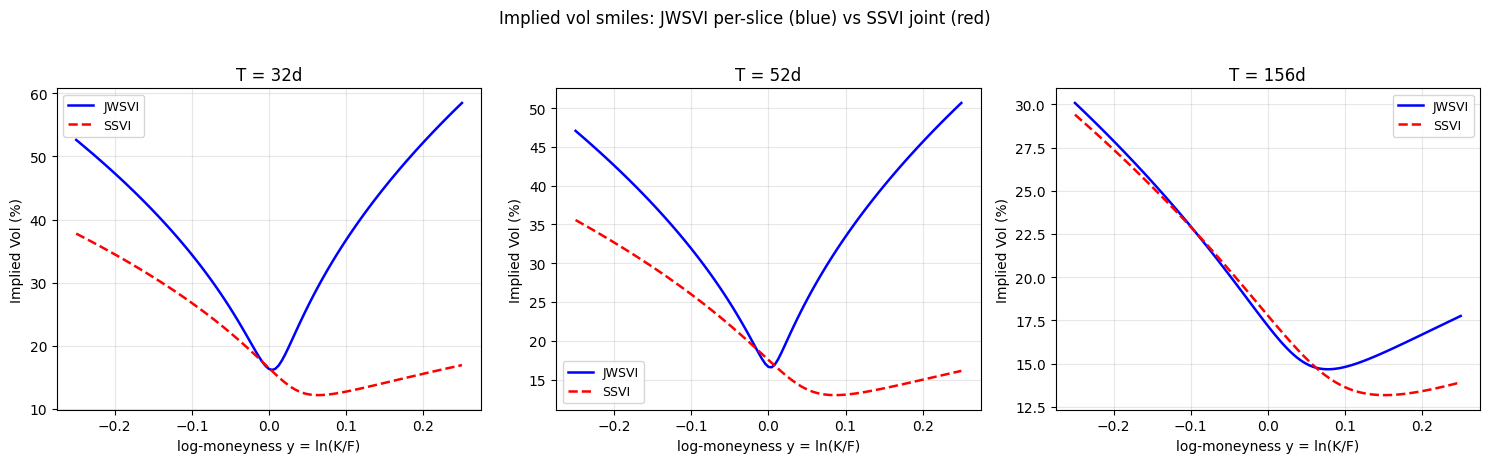

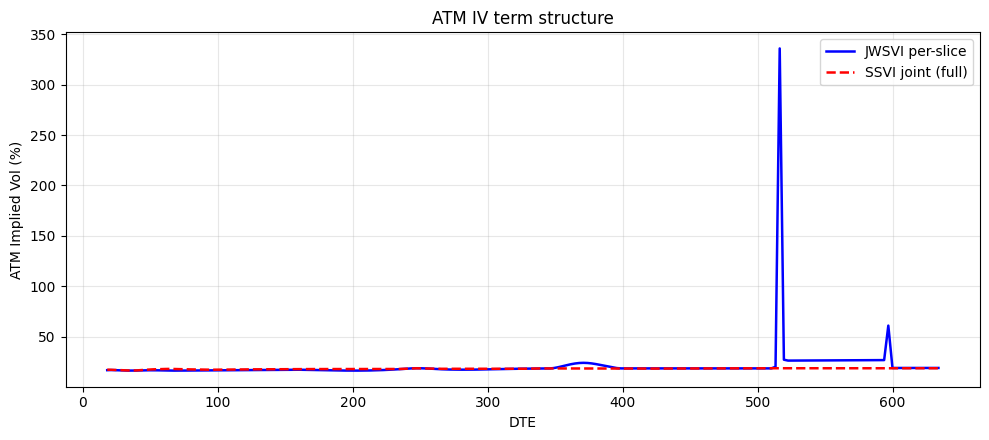

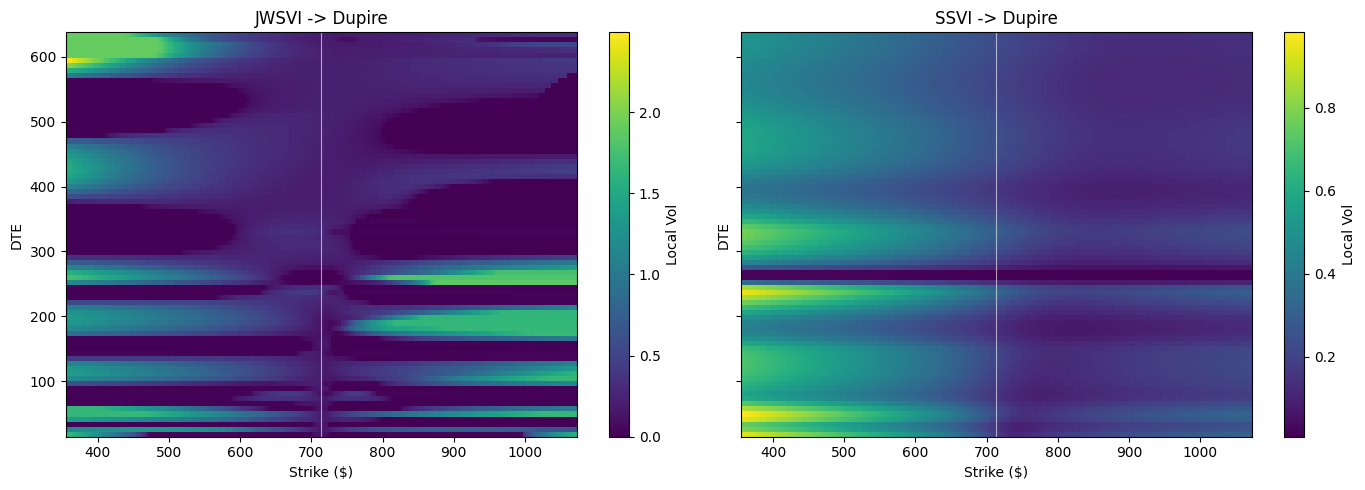

In [21]:
# Smile overlay at three representative tenors
y_grid = np.linspace(-0.25, 0.25, 121)
target_dcfs = [vol_surface_first := jwsvi_surface.dcfs[len(jwsvi_surface.dcfs)//8],
               jwsvi_surface.dcfs[len(jwsvi_surface.dcfs)//4],
               jwsvi_surface.dcfs[len(jwsvi_surface.dcfs)//2]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t_q in zip(axes, target_dcfs):
    fwd = spot * np.exp((r - q) * t_q)
    K_grid = fwd * np.exp(y_grid)
    iv_jw   = jwsvi_surface.implied_vol(K_grid, t_q)
    iv_ssvi = ssvi_surface.implied_vol(K_grid, t_q)
    ax.plot(y_grid, iv_jw   * 100, 'b-',  lw=1.8, label='JWSVI')
    ax.plot(y_grid, iv_ssvi * 100, 'r--', lw=1.8, label='SSVI')
    ax.set_xlabel('log-moneyness y = ln(K/F)')
    ax.set_ylabel('Implied Vol (%)')
    ax.set_title(f'T = {t_q*365:.0f}d')
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle('Implied vol smiles: JWSVI per-slice (blue) vs SSVI joint (red)', y=1.02)
plt.tight_layout(); plt.show()

# ATM IV term structure overlay
dcf_plot = np.linspace(jwsvi_surface.dcfs[0], jwsvi_surface.dcfs[-1], 200)
atm_jw   = np.array([jwsvi_surface.implied_vol(np.array([spot*np.exp((r-q)*d)]), d)[0] for d in dcf_plot])
atm_ssvi = np.array([ssvi_surface.implied_vol (np.array([spot*np.exp((r-q)*d)]), d)[0] for d in dcf_plot])
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(dcf_plot * 365, atm_jw   * 100, 'b-',  lw=1.8, label='JWSVI per-slice')
ax.plot(dcf_plot * 365, atm_ssvi * 100, 'r--', lw=1.8, label='SSVI joint (full)')
ax.set_xlabel('DTE'); ax.set_ylabel('ATM Implied Vol (%)')
ax.set_title('ATM IV term structure')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Local-vol surface heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, lv, title in [(axes[0], jwsvi_lv, 'JWSVI -> Dupire'),
                      (axes[1], ssvi_lv,  'SSVI -> Dupire')]:
    K_mesh, dcf_mesh = np.meshgrid(lv.K_grid, lv.dcf_grid * 365)
    im = ax.pcolormesh(K_mesh, dcf_mesh, lv.lv_grid_data, shading='auto', cmap='viridis')
    ax.axvline(spot, color='w', lw=0.8, alpha=0.6)
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('DTE')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Local Vol')
plt.tight_layout(); plt.show()


## 3. Arbitrage diagnostics (calendar arb is the headline number)

JWSVI per-slice independently fits each smile -> calendar arbitrage between adjacent expiries can occur on noisy data.  SSVI joint calibration is calendar-arbitrage-free **by construction** when $\theta(t)$ is monotone and $\gamma\in[0, 1/2]$ (which the calibrator enforces).


In [17]:
K_chk = np.linspace(spot * 0.8, spot * 1.2, 80)

print(f'{"Check":<28s} {"JWSVI":>16s} {"SSVI":>16s}')
print('-' * 64)

# 1. Calendar
jw_ok, jw_n, _ = check_calendar_arbitrage(jwsvi_surface, K_chk)
ss_ok, ss_n, _ = check_calendar_arbitrage(ssvi_surface,  K_chk)
print(f'{"Calendar arbitrage":<28s} '
      f'{("PASS" if jw_ok else f"{jw_n} viol."):>16s} '
      f'{("PASS" if ss_ok else f"{ss_n} viol."):>16s}')

# 2. Per-slice butterfly: count slices that fail
def _butterfly_summary(surf):
    n_fail = 0; n_total = 0
    for d in surf.dcfs:
        svi = surf.get_svi_at(d)
        ok, n_v, gm = check_butterfly_arbitrage(svi, d)
        n_total += 1
        if not ok: n_fail += 1
    return n_fail, n_total

jw_bf, jw_t = _butterfly_summary(jwsvi_surface)
ss_bf, ss_t = _butterfly_summary(ssvi_surface)
print(f'{"Butterfly (slices failing)":<28s} '
      f'{f"{jw_bf}/{jw_t}":>16s} '
      f'{f"{ss_bf}/{ss_t}":>16s}')

# 3. Spread arb at the longest tenor (representative)
T_chk = jwsvi_surface.dcfs[len(jwsvi_surface.dcfs)//2]
jw_sp_ok, jw_sp_n, _ = check_spread_arbitrage(jwsvi_surface, T_chk, K_chk, r=r)
ss_sp_ok, ss_sp_n, _ = check_spread_arbitrage(ssvi_surface,  T_chk, K_chk, r=r)
print(f'{"Spread @ mid-tenor":<28s} '
      f'{("PASS" if jw_sp_ok else f"{jw_sp_n} viol."):>16s} '
      f'{("PASS" if ss_sp_ok else f"{ss_sp_n} viol."):>16s}')


Check                                   JWSVI             SSVI
----------------------------------------------------------------
Calendar arbitrage                  445 viol.             PASS
Butterfly (slices failing)               7/19             0/19
Spread @ mid-tenor                       PASS             PASS


## 4. Price an Asian call (antithetic MC, two surfaces)


In [18]:
T = 0.5      # 6 months
n_obs = 126  # ~daily
K = spot     # ATM
n_paths = 200_000

def _price_under(surf, lv, label):
    pricer = AsianMCPricer(S0=spot, r=r, T=T, n_obs=n_obs,
                           vol_surface=surf, local_vol_surface=lv)
    np.random.seed(42)
    res = pricer.price_asian(K, n_paths)
    print(f'  {label:<20s} ${res["price"]:9.4f}  +/- ${res["std_err"]:.4f}  '
          f'95% CI [${res["ci_95"][0]:.4f}, ${res["ci_95"][1]:.4f}]')
    return res

print(f'ATM 6M Asian call (n_paths={n_paths:,}):')
res_jw   = _price_under(jwsvi_surface, jwsvi_lv, 'JWSVI per-slice')
res_ssvi = _price_under(ssvi_surface,  ssvi_lv,  'SSVI joint (full)')
print(f'\n  diff (SSVI - JWSVI) = ${res_ssvi["price"] - res_jw["price"]:+.4f}  '
      f'({(res_ssvi["price"] - res_jw["price"]) / res_jw["price"] * 100:+.2f}%)')


ATM 6M Asian call (n_paths=200,000):
  JWSVI per-slice      $  23.4560  +/- $0.1166  95% CI [$23.2274, $23.6846]
  SSVI joint (full)    $  23.1171  +/- $0.0563  95% CI [$23.0067, $23.2275]

  diff (SSVI - JWSVI) = $-0.3390  (-1.45%)


## 5. Greeks (finite difference under common random numbers, both surfaces)


In [19]:
def _greeks_under(surf, lv, label, call=True):
    g = compute_greeks(spot, K, r, T, n_obs, surf, lv,
                       n_paths=120_000, call=call)
    return g

g_jw_call  = _greeks_under(jwsvi_surface, jwsvi_lv, 'JWSVI', call=True)
g_jw_put   = _greeks_under(jwsvi_surface, jwsvi_lv, 'JWSVI', call=False)
g_ss_call  = _greeks_under(ssvi_surface,  ssvi_lv,  'SSVI',  call=True)
g_ss_put   = _greeks_under(ssvi_surface,  ssvi_lv,  'SSVI',  call=False)

print(f'{"Greek":<8s} {"JWSVI Call":>12s} {"JWSVI Put":>12s} {"SSVI Call":>12s} {"SSVI Put":>12s}')
print('-' * 60)
for k in ('price', 'delta', 'gamma', 'vega', 'theta'):
    print(f'{k:<8s} {g_jw_call[k]:>12.4f} {g_jw_put[k]:>12.4f} '
          f'{g_ss_call[k]:>12.4f} {g_ss_put[k]:>12.4f}')

# Delta parity sanity (European: delta_call - delta_put = exp(-q*T))
print(f'\nDelta parity exp(-q*T) = {np.exp(-q*T):.4f}')
print(f'  JWSVI: delta_call - delta_put = {g_jw_call["delta"] - g_jw_put["delta"]:+.4f}')
print(f'  SSVI : delta_call - delta_put = {g_ss_call["delta"] - g_ss_put["delta"]:+.4f}')
print('  (Asian only approximately satisfies European parity due to averaging.)')


Greek      JWSVI Call    JWSVI Put    SSVI Call     SSVI Put
------------------------------------------------------------
price         23.4836      19.0266      23.1054      18.6958
delta          0.5050      -0.4897       0.3994      -0.5891
gamma          0.0046       0.0045       0.0081       0.0081
vega           1.3046       1.3096       1.2122       1.2127
theta         -0.0819      -0.0769      -0.0733      -0.0501

Delta parity exp(-q*T) = 0.9943
  JWSVI: delta_call - delta_put = +0.9947
  SSVI : delta_call - delta_put = +0.9885
  (Asian only approximately satisfies European parity due to averaging.)


## 6. MC convergence: SE vs path count (JWSVI surface, antithetic only)

Standard error scales as $1/\sqrt{N}$.  We show the JWSVI run only since the convergence behaviour is identical for both surfaces (it depends on the MC engine, not the surface).


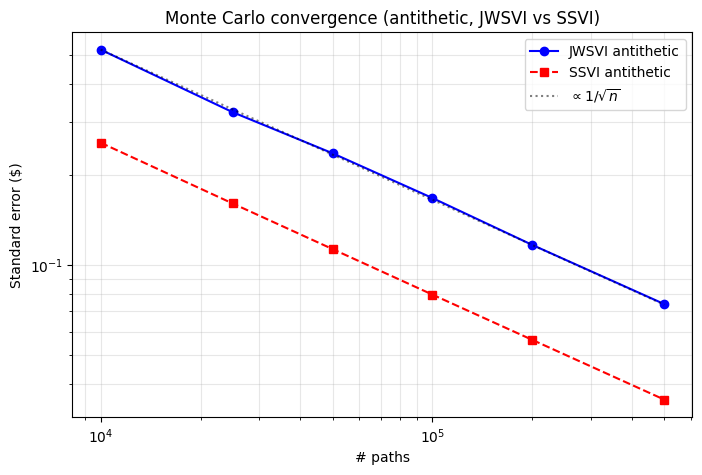

In [20]:
paths = [10_000, 25_000, 50_000, 100_000, 200_000, 500_000]
se_jw, se_ss = [], []
pricer_jw = AsianMCPricer(S0=spot, r=r, T=T, n_obs=n_obs,
                          vol_surface=jwsvi_surface, local_vol_surface=jwsvi_lv)
pricer_ss = AsianMCPricer(S0=spot, r=r, T=T, n_obs=n_obs,
                          vol_surface=ssvi_surface,  local_vol_surface=ssvi_lv)
for n in paths:
    np.random.seed(42); se_jw.append(pricer_jw.price_asian(K, n)['std_err'])
    np.random.seed(42); se_ss.append(pricer_ss.price_asian(K, n)['std_err'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(paths, se_jw, 'b-o', label='JWSVI antithetic')
ax.loglog(paths, se_ss, 'r--s', label='SSVI antithetic')
# Reference 1/sqrt(n) line, anchored to the first JWSVI point
ref = se_jw[0] * np.sqrt(paths[0] / np.array(paths))
ax.loglog(paths, ref, 'k:', alpha=0.5, label=r'$\propto 1/\sqrt{n}$')
ax.set_xlabel('# paths'); ax.set_ylabel('Standard error ($)')
ax.set_title('Monte Carlo convergence (antithetic, JWSVI vs SSVI)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.show()
